# Translating Images into Maps (TIIM) lifting, step by step 🧭
### "Every image *column* is a ray on the map": a transformer turns a column of pixels into a ray of depth cells

**Lifter name:** `tiim` · **class:** `PolarRayLifter` · **paper:** *Translating Images into Maps* (Saha et al., ICRA 2022)

TIIM's insight comes from a simple geometric fact: **the vertical axis of an image encodes distance, the horizontal axis encodes direction.**
On the ground, pixels lower in the image are closer to the camera. So a single image **column** (top to bottom) maps onto a single **ray**
in the map (near to far). TIIM therefore:

1. treats each image column as a 1D sequence of `H` pixels,
2. uses a **transformer** to translate that sequence into a sequence of `D` depth cells (a "polar ray"),
3. stacks the rays into a polar map `(C, D, W)`, which is then
4. **resampled** onto the Cartesian BEV grid with plain geometry.

| Step | Question |
|---|---|
| 0 | Setup and data |
| 1 | Why a column is a ray (with real depth data) |
| 2 | The polar → Cartesian mapping (a fan of rays) |
| 3 | Resampling the polar map onto the grid (with an exact test) |
| 4 | Image columns → polar rays with a transformer |
| 5 | The complete lifter |
| 6 | Train and test |
| 7 | Exercises |

## Step 0: Setup and the data

> New to this repo? The notebook `tpv_lifting_step_by_step.ipynb` explains `GridSpec`, `Cameras` and the synthetic
> data in more detail. Here is the short version.

* **Ego frame:** `x` forward, `y` left, `z up` (metres). A `GridSpec` chops a box of the world into cells.
* **Cameras:** `cameras.project(points)` maps 3D ego points to pixels `(u, v)` and a depth `d`
  (*easy direction*). Going back from a pixel needs the depth (*hard direction*).
* **Data:** procedurally rendered street scenes with 4 cameras, red *vehicles* and blue *pedestrians*.
  The task is **BEV semantic segmentation**: predict the top-down class map (`0` empty, `1` vehicle, `2` pedestrian)
  from the 4 images alone. The whole camera rig is randomly rotated in every scene, so the network *has to use the calibration*.

In [1]:
import math, time, dataclasses
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

from lifting import GridSpec, Cameras, build_bev_model
from lifting.data import SceneBatch, SyntheticSceneDataset
from lifting.geometry import DepthBins
from lifting.training import BEVSegmentationTask, Trainer

torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest"})
print("torch", torch.__version__)
from lifting.lifters import PolarRayLifter
from lifting.encoders import SimpleConvEncoder

torch 2.14.1


images: (4, 4, 3, 48, 96) = (B, N cameras, 3, H, W)
BEV labels: (4, 32, 32) = (B, X, Y)


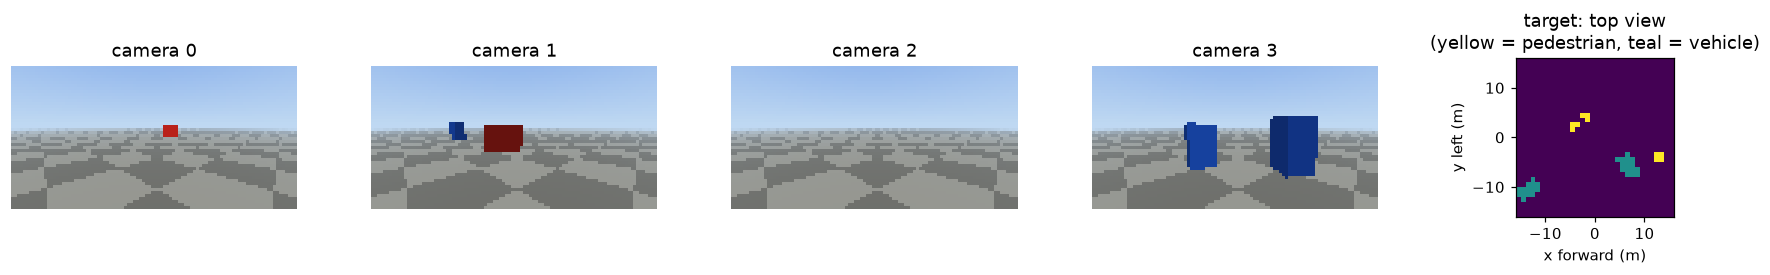

In [2]:
grid = GridSpec(resolution=(32, 32, 4))          # 32 x 32 x 4 cells of 1 m^3 over a 32 m x 32 m x 4 m box
data = SyntheticSceneDataset(256, grid, seed=1)
batch = SceneBatch.collate([data[i] for i in range(4)])
cams = batch.cameras
ext = [grid.x_bounds[0], grid.x_bounds[1], grid.y_bounds[0], grid.y_bounds[1]]
print("images:", tuple(batch.images.shape), "= (B, N cameras, 3, H, W)")
print("BEV labels:", tuple(batch.bev_labels.shape), "= (B, X, Y)")

fig, ax = plt.subplots(1, 5, figsize=(16, 2.6))
for n in range(4):
    ax[n].imshow(batch.images[0, n].permute(1, 2, 0)); ax[n].set_title(f"camera {n}"); ax[n].axis("off")
ax[4].imshow(batch.bev_labels[0].T, origin="lower", vmin=0, vmax=2, extent=ext)
ax[4].set_title("target: top view\n(yellow = pedestrian, teal = vehicle)"); ax[4].set_xlabel("x forward (m)"); ax[4].set_ylabel("y left (m)")
plt.tight_layout(); plt.show()

In [3]:
import os, sys
for _p in (".", "notebooks", os.path.join("..", "notebooks")):          # find lifting_diagrams.py next to the notebooks
    if os.path.exists(os.path.join(_p, "lifting_diagrams.py")):
        sys.path.insert(0, _p); break
import lifting_diagrams as dg

### 🖼️ Diagram: the TIIM idea in one picture
**1.** one image column (top to bottom) → **2.** a transformer turns its `H` pixels into `D` depth cells of the polar map → **3.** that column of the polar map is a ray on the bird's-eye map.

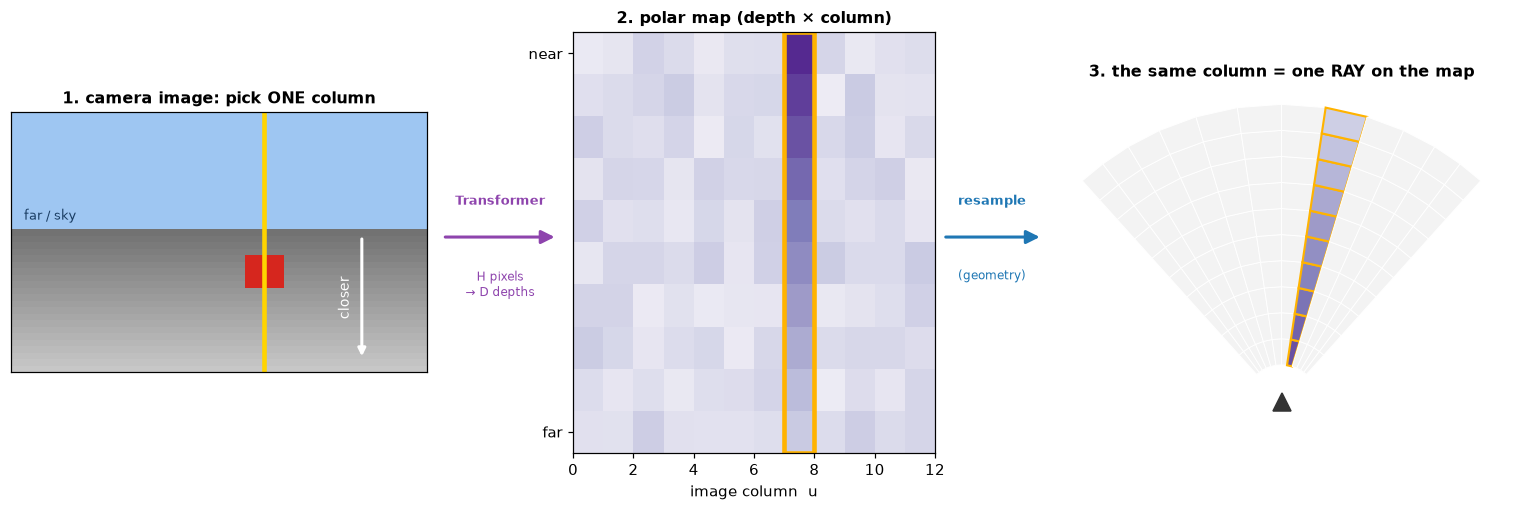

In [4]:
dg.fig_tiim_column_to_ray()

## Step 1: Why a column is a ray

For a camera at height 1.6 m looking roughly horizontally over flat ground, a ground point at distance `d` appears at image row
$v \approx v_0 + f\,h/d$: **closer points are lower in the image**. We can verify this with the dataset's ground-truth depth: for a few image columns, plot depth against the row.
Sky pixels have infinite depth (left out).

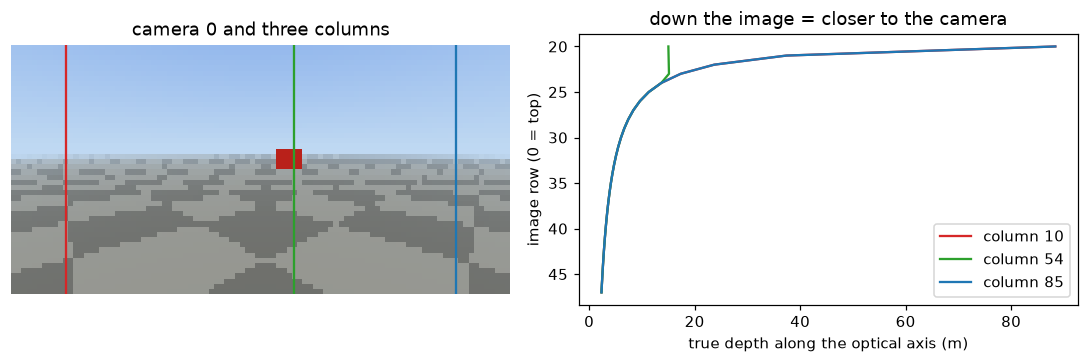

In [5]:
depth = batch.depth[0, 0].clone()                           # (48, 96) camera 0
depth[~torch.isfinite(depth)] = float("nan")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].imshow(batch.images[0, 0].permute(1, 2, 0))
for col, c in zip((10, 54, 85), ("tab:red", "tab:green", "tab:blue")):
    ax[0].axvline(col, color=c)
    ax[1].plot(depth[:, col], np.arange(48), c=c, label=f"column {col}")
ax[0].set_title("camera 0 and three columns"); ax[0].axis("off")
ax[1].invert_yaxis(); ax[1].set_xlabel("true depth along the optical axis (m)"); ax[1].set_ylabel("image row (0 = top)")
ax[1].set_title("down the image = closer to the camera"); ax[1].legend()
plt.tight_layout(); plt.show()

On flat ground all columns give the *same* curve (the three curves overlap), a smooth monotone function; the column through the red box (green) departs from it where the box stands in front of the ground.
A transformer along the column can learn this **row → depth** relationship *and* where objects interrupt it.
That translation is the learned part of TIIM.

## Step 2: The polar → Cartesian mapping

After the transformer we have a **polar map** whose axes are (image column `u`, depth `d`). To get a normal BEV image we ask, for every BEV cell:
*which `(column, depth)` of this camera does the cell correspond to?* That is just `cameras.project` again (taking the cell centre at mid-height).
Below: for camera 0, each BEV cell coloured by its image column and by its depth. Columns form a **fan of rays**; depths form **bands** across the fan.

polar-valid cells for camera 0: 278 of 1024


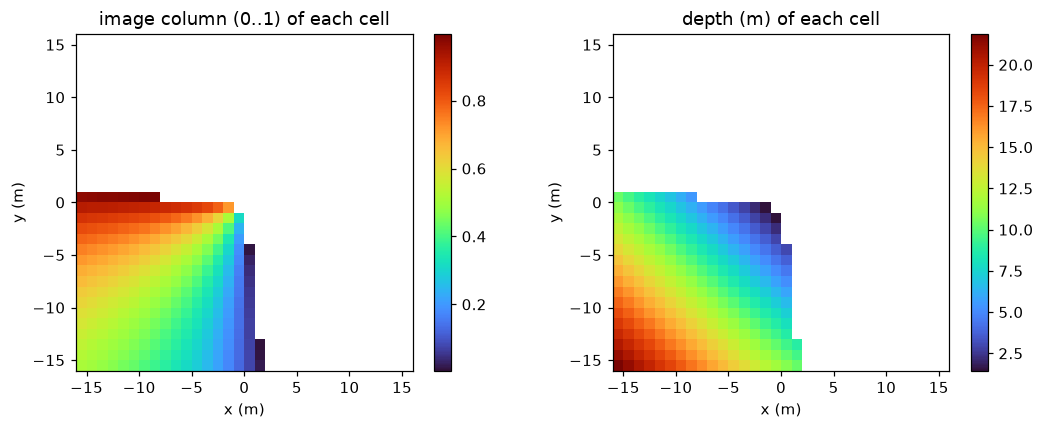

In [6]:
tiim = PolarRayLifter(grid, in_channels=32, out_channels=32, num_layers=1)
bins = tiim.depth_bins
centers = grid.voxel_centers()[:, :, 0].clone()                 # (X, Y, 3)
centers[..., 2] = 0.5 * sum(grid.z_bounds)                      # use mid-height
uv, depth, valid = cams.project(centers.view(1, -1, 3).expand(4, -1, -1))
u_norm = 2.0 * uv[..., 0] / cams.image_size[1] - 1.0
ok = (depth > 0) & (u_norm.abs() < 1.0) & bins.contains(depth)
print("polar-valid cells for camera 0:", ok[0, 0].sum().item(), "of", grid.num_cells_bev)

def show(vals, title, ax):
    img = torch.where(ok[0, 0], vals[0, 0], torch.tensor(float("nan"))).view(*grid.bev_shape)
    im = ax.imshow(img.T, origin="lower", extent=ext, cmap="turbo"); plt.colorbar(im, ax=ax, fraction=0.046); ax.set_title(title)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
show((uv[..., 0] / 96.0), "image column (0..1) of each cell", ax[0])
show(depth, "depth (m) of each cell", ax[1])
plt.tight_layout(); plt.show()

## Step 3: Resample the polar map onto the grid: `polar_to_bev`

`polar_to_bev(polar, cameras)` samples the polar map `(B, N, C, D, W)` at each cell's `(u_norm, depth_norm)` with bilinear interpolation
and averages over the cameras for which the cell is valid. No learned parameters here.

**Exact test:** build a polar map that stores its own coordinates: channel 0 = depth of the row, channel 1 = column position.
Warping it must give every BEV cell its own camera depth and its own `u/W`.

In [7]:
d_bins = bins.num_bins
Wf = 24
depth_ramp = bins.centers().view(1, 1, d_bins, 1).expand(1, 1, d_bins, Wf)                   # value = depth of the bin
col_ramp = ((torch.arange(Wf) + 0.5) / Wf).view(1, 1, 1, Wf).expand(1, 1, d_bins, Wf)         # value = u / W
polar = torch.stack([depth_ramp, col_ramp], dim=2).expand(4, 1, 2, d_bins, Wf).contiguous()  # (B, N=1, C=2, D, W)

cam0 = Cameras(cams.intrinsics[:, :1], cams.cam_to_ego[:, :1], cams.image_size)
with torch.no_grad():
    bev = tiim.polar_to_bev(polar, cam0)                                                      # (B, 2, X, Y)

uv0, depth0, valid0 = uv[:, 0], depth[:, 0], ok[:, 0]
m = 5.0
inner = valid0 & (uv0[..., 0] > m) & (uv0[..., 0] < 96 - m) & (depth0 > bins.min_depth + bins.step / 2) & (depth0 < bins.max_depth - bins.step / 2)
e_depth = (bev[:, 0].flatten(1) - depth0)[inner].abs().max()
e_col = (bev[:, 1].flatten(1) - uv0[..., 0] / 96.0)[inner].abs().max()
print(f"{inner.sum().item()} cells checked: max depth error {e_depth:.2e} m, max column error {e_col:.2e}")
assert e_depth < 1e-3 and e_col < 1e-4
print("✓ polar_to_bev puts every polar (column, depth) at the cell that camera 0 sees there")

1052 cells checked: max depth error 1.91e-06 m, max column error 1.19e-07
✓ polar_to_bev puts every polar (column, depth) at the cell that camera 0 sees there


## Step 4: From image columns to polar rays, with a transformer

`image_to_polar(features)`:

1. **Each column is a sequence.** A feature map `(B, N, C, H, W)` becomes `B·N·W` sequences of `H` tokens (each of size `C`).
2. Add a learned **row embedding** (an MLP of the normalised row) so the model knows *where in the column* each token sits.
3. A **transformer encoder** lets the pixels of a column talk to each other (self-attention): "the ground continues here, a car starts there".
4. `D` learned **depth queries** (one per depth bin) *cross-attend* to the encoded column in a **transformer decoder**, producing one feature vector per depth cell.
5. Reshape back: `(B, N, C, D, W)`.

In [8]:
enc = SimpleConvEncoder(out_channels=32, num_levels=2)
with torch.no_grad():
    feats = [f.view(4, 4, *f.shape[1:]) for f in enc(batch.images.flatten(0, 1))]
f0 = feats[0]
B, N, C, Hf, Wf = f0.shape
print("feature map     :", tuple(f0.shape), "= (B, N, C, H, W)")
print(f"column sequences: {B * N * Wf} sequences of {Hf} tokens (B*N*W, H, C)")
print("depth queries   :", tuple(tiim.depth_queries.shape), "= (D, C): one learned vector per depth bin")

with torch.no_grad():
    polar_pred = tiim.image_to_polar(f0)
print("polar rays      :", tuple(polar_pred.shape), "= (B, N, C, D, W)")
parts = {"row embedding": tiim.row_embed, "column encoder": tiim.column_encoder, "ray decoder": tiim.ray_decoder, "output convs": tiim.output}
for k, mod in parts.items():
    print(f"  {k:15s} {sum(p.numel() for p in mod.parameters()):>8,} params")
print(f"  {'depth queries':15s} {tiim.depth_queries.numel():>8,} params")

feature map     : (4, 4, 32, 12, 24) = (B, N, C, H, W)
column sequences: 384 sequences of 12 tokens (B*N*W, H, C)
depth queries   : (24, 32) = (D, C): one learned vector per depth bin
polar rays      : (4, 4, 32, 24, 24) = (B, N, C, D, W)
  row embedding      1,120 params
  column encoder     8,544 params
  ray decoder       12,832 params
  output convs      10,336 params
  depth queries        768 params


> 💡 Cost: the transformer attends only *within one column* (`H = 12` tokens), never across the whole image, which is why this is cheap compared to full attention.
> The price is that the **column is processed in isolation**: left and right neighbours are only combined by the convolutional encoder and the decoder afterwards.

## Step 5: The complete lifter

```python
polar = self.image_to_polar(features[self.level])   # Step 4: learned, (B, N, C, D, W)
bev   = self.polar_to_bev(polar, cameras)            # Step 3: geometry,  (B, C, X, Y)
return self.output(bev)                               # conv3x3 + conv1x1
```

### 🖼️ Diagram: the whole TIIM lifter

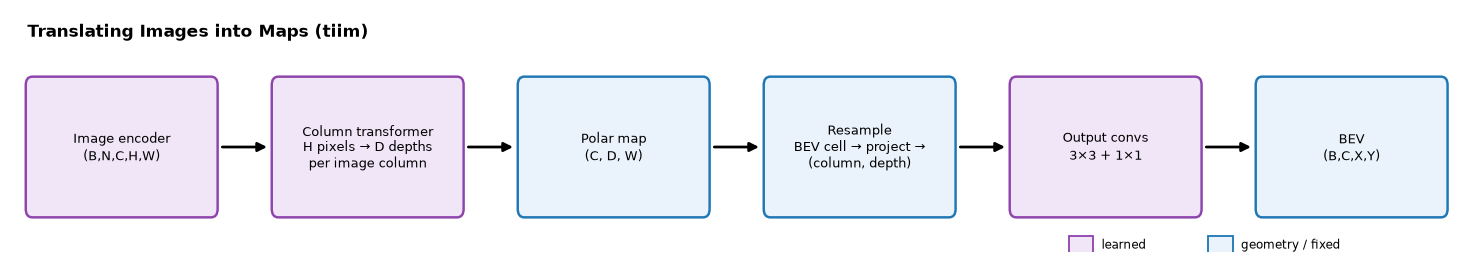

In [9]:
dg.pipeline([('Image encoder', '(B,N,C,H,W)'), ('Column transformer', 'H pixels → D depths\nper image column'), ('Polar map', '(C, D, W)'), ('Resample', 'BEV cell → project →\n(column, depth)'), ('Output convs', '3×3 + 1×1'), ('BEV', '(B,C,X,Y)')], 'Translating Images into Maps (tiim)', learned=(0, 1, 4))

In [10]:
with torch.no_grad():
    bev = tiim(feats, cams)
print("BEV:", tuple(bev.shape), "  lifter parameters:", f"{sum(p.numel() for p in tiim.parameters()):,}")

BEV: (4, 32, 32, 32)   lifter parameters: 33,600


## Final step: plug it into a full model, train, and test it

`build_bev_model("tiim", ...)` = **image encoder → `tiim` lifter → BEV decoder (small U-Net) → segmentation head**.
Only the lifter changes between methods. Loss is weighted cross-entropy on the BEV map; the metric is the mean IoU of the two foreground classes.
Training uses 192 scenes and the score is measured on 64 **unseen** scenes.

In [11]:
torch.manual_seed(0)
def make_batches(lo, hi, bs=4):
    return [SceneBatch.collate([data[i + j] for j in range(bs)]) for i in range(lo, hi, bs)]
train_batches, test_batches = make_batches(0, 192), make_batches(192, 256)

model = build_bev_model("tiim", grid, num_classes=3, image_size=(48, 96), num_cameras=4, channels=32)
n_total = sum(p.numel() for p in model.parameters()); n_lift = sum(p.numel() for p in model.lifter.parameters())
print(f"parameters: {n_total:,} total, {n_lift:,} in the lifter")

trainer = Trainer(model, BEVSegmentationTask(num_classes=3))
print("mIoU before training:", round(trainer.evaluate(test_batches).mean_foreground(), 3))
t0 = time.time()
trainer.fit(train_batches, steps=250)
print(f"trained 250 steps in {time.time() - t0:.0f}s")
print("mIoU after training :", round(trainer.evaluate(test_batches).mean_foreground(), 3))

parameters: 652,803 total, 33,600 in the lifter


mIoU before training: 0.019


trained 250 steps in 55s


mIoU after training : 0.394


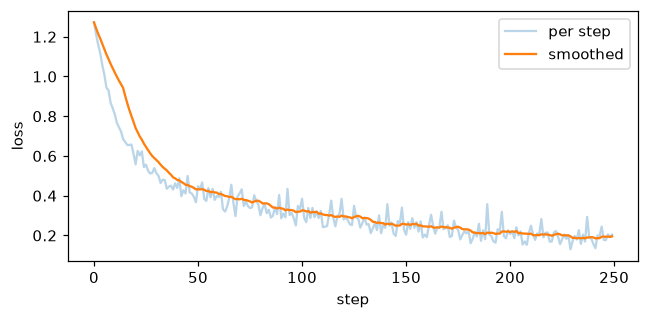

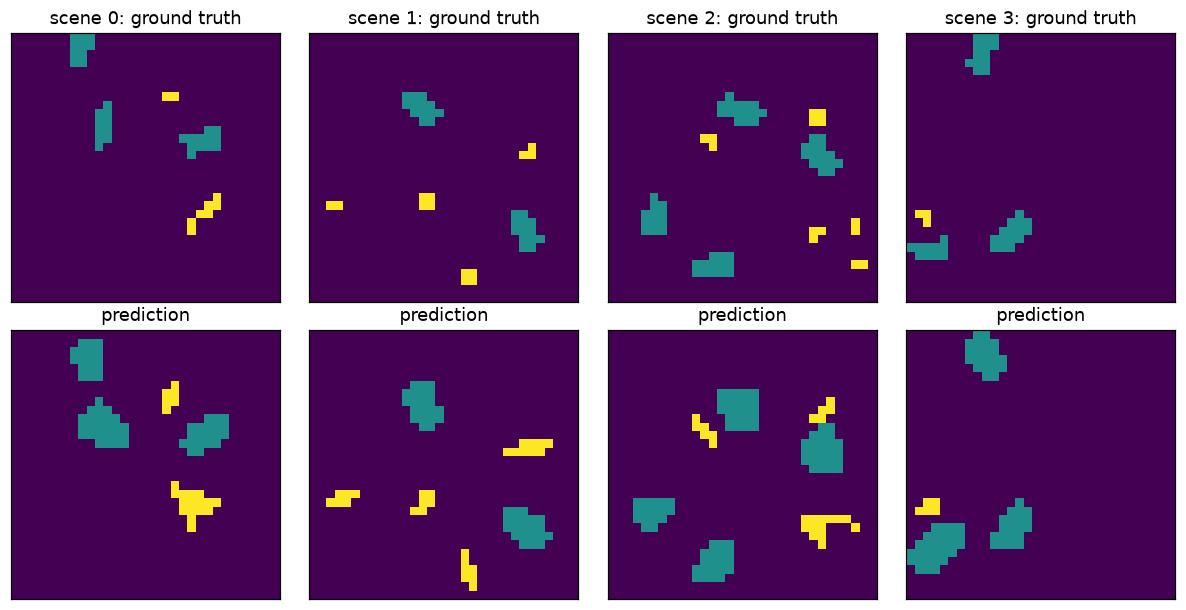

In [12]:
plt.figure(figsize=(6, 3))
plt.plot(trainer.history.losses, alpha=0.3, label="per step"); plt.plot(trainer.history.smoothed(15), label="smoothed")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

tb = test_batches[0]
pred = trainer.predict(tb)
fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for s in range(4):
    ax[0, s].imshow(tb.bev_labels[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[0, s].set_title(f"scene {s}: ground truth")
    ax[1, s].imshow(pred[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[1, s].set_title("prediction")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### Does it really use the geometry? 🔬
Keep images and labels fixed, but **rotate the camera extrinsics by 90°**. A lifter that truly maps pixels to the world through
the calibration must now fail. (`lifting-verify` does this for every lifter.)

In [13]:
Rz = torch.eye(4); Rz[0, 0], Rz[0, 1], Rz[1, 0], Rz[1, 1] = 0.0, -1.0, 1.0, 0.0     # 90 degrees about z
rotate_rig = lambda b: dataclasses.replace(b, cameras=b.cameras.transformed(Rz))

good = trainer.evaluate(test_batches).mean_foreground()
bad  = trainer.evaluate(test_batches, transform=rotate_rig).mean_foreground()
print(f"mIoU, correct extrinsics: {good:.3f}")
print(f"mIoU, rotated extrinsics: {bad:.3f}   -> drops by {100 * (1 - bad / max(good, 1e-9)):.0f}%")

mIoU, correct extrinsics: 0.394
mIoU, rotated extrinsics: 0.020   -> drops by 95%


## Step 7: Recap and exercises

```
feature map (C,H,W) ─► each column = sequence of H tokens ─► transformer ─► D depth cells ─► polar map (C,D,W)
BEV cell ─► project into camera ─► (column, depth) ─► bilinear read of the polar map ─► mean over cameras ─► conv ─► BEV
```
**Pros:** very cheap attention; learns the row↔depth relation explicitly; no depth supervision needed; works for any number of cameras.
**Cons:** the column is translated *independently* (no left/right context in the transformer); the flat-ground intuition breaks for tall structures; the cell height is fixed to the grid's mid-height, so
the lifter produces a **2D** BEV map directly (no height axis).

### 🧪 Exercises
1. Change `num_layers` of `PolarRayLifter` from 1 to 2 or 3. Does mIoU improve? What is the cost?
2. Make the depth bins finer: `DepthBins(1, 25, 48)` (pass `depth_bins=` via `build_bev_model`).
3. In Step 3 replace the `z` of the cell centres by a different height. What happens to the cell → (column, depth) map for tall objects?
4. Visualise the polar map of a trained model for one camera (`model.lifter.image_to_polar`): do bright rays appear where vehicles are?
5. Compare the training curve with Simple-BEV: which learns faster at first?